PARI stack size set to 6000000000 bytes, maximum size set to 6000001024
PARI stack size set to: 6.00 GB
Memoization setup complete
Functions defined
Computing j_list...
Progress: n=50/400
Progress: n=100/400
Progress: n=150/400
Progress: n=200/400
Progress: n=250/400
Progress: n=300/400
Progress: n=350/400
Progress: n=400/400
j_list computed with 401 elements
j_list saved to /Users/barrybrent/data2/run27nov25no1.txt
P_matrix function defined
Setup complete for matrix computations
Computing matrices and roots...
Progress: n=20/400
Progress: n=40/400
Progress: n=60/400
Progress: n=80/400
Progress: n=100/400
Progress: n=120/400
Progress: n=140/400
Progress: n=160/400
Progress: n=180/400
Progress: n=200/400
Progress: n=220/400
Progress: n=240/400
Progress: n=260/400
Progress: n=280/400
Progress: n=300/400
Progress: n=320/400
Progress: n=340/400
Progress: n=360/400
Progress: n=380/400
Progress: n=400/400
Computation complete!
Generating plots...
MINIMUM MODULI


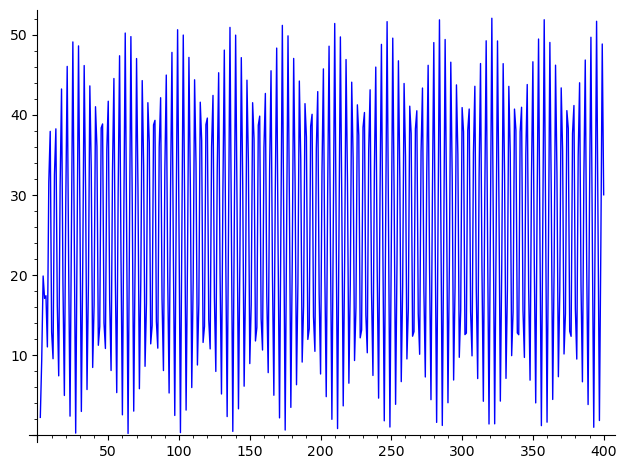

LOGS MINIMUM MODULI


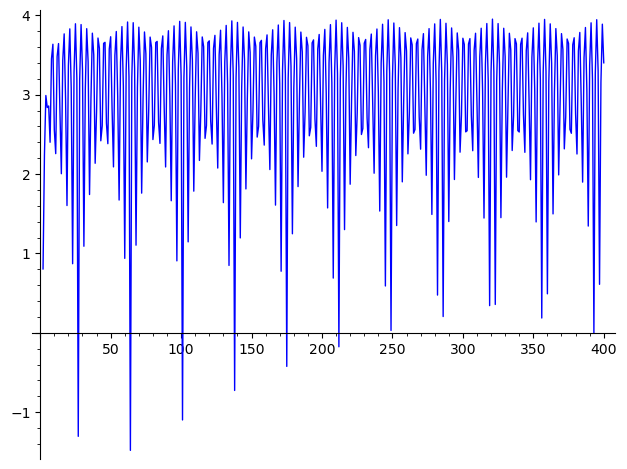

minimum logarithm of minimum modulus: -1.4819234769066430204168644894283?
MAXIMUM MODULI


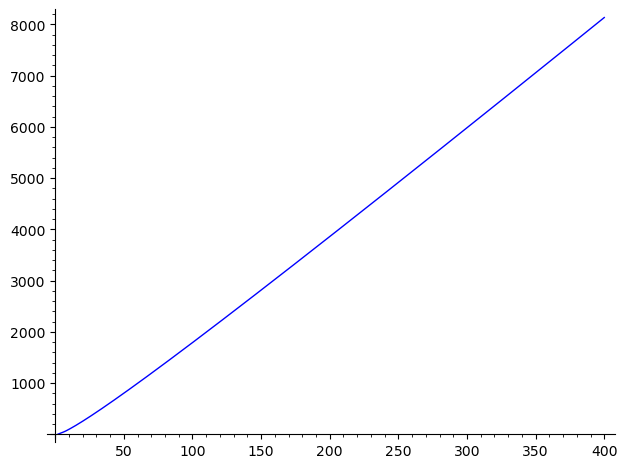

LOGS MAXIMUM MODULI


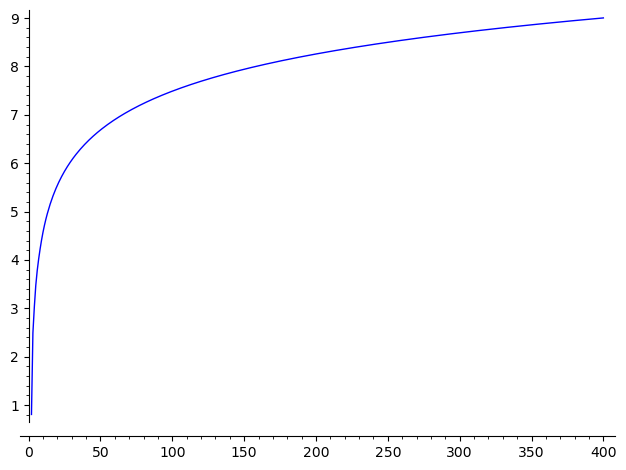

Saving results...
All results saved!
Output files saved to: /Users/barrybrent/data2/
Data range: n = 2 to 400
Number of data points: 399
Min modulus range: 0.227200 to 52.067661
Log min modulus range: -1.481923 to 3.952544

Polynomial trend coefficients: [-2.40901145e-06  1.25494764e-03  2.81962283e+00]
Detrended data std dev: 0.9740

TOP DOMINANT PERIODICITIES (in index n)
Rank   Period       Frequency    Power          
----------------------------------------------------------------------
1            4.11     0.243108       5.40e+04
2            2.06     0.486216       7.63e+03
3            3.69     0.270677       4.62e+03


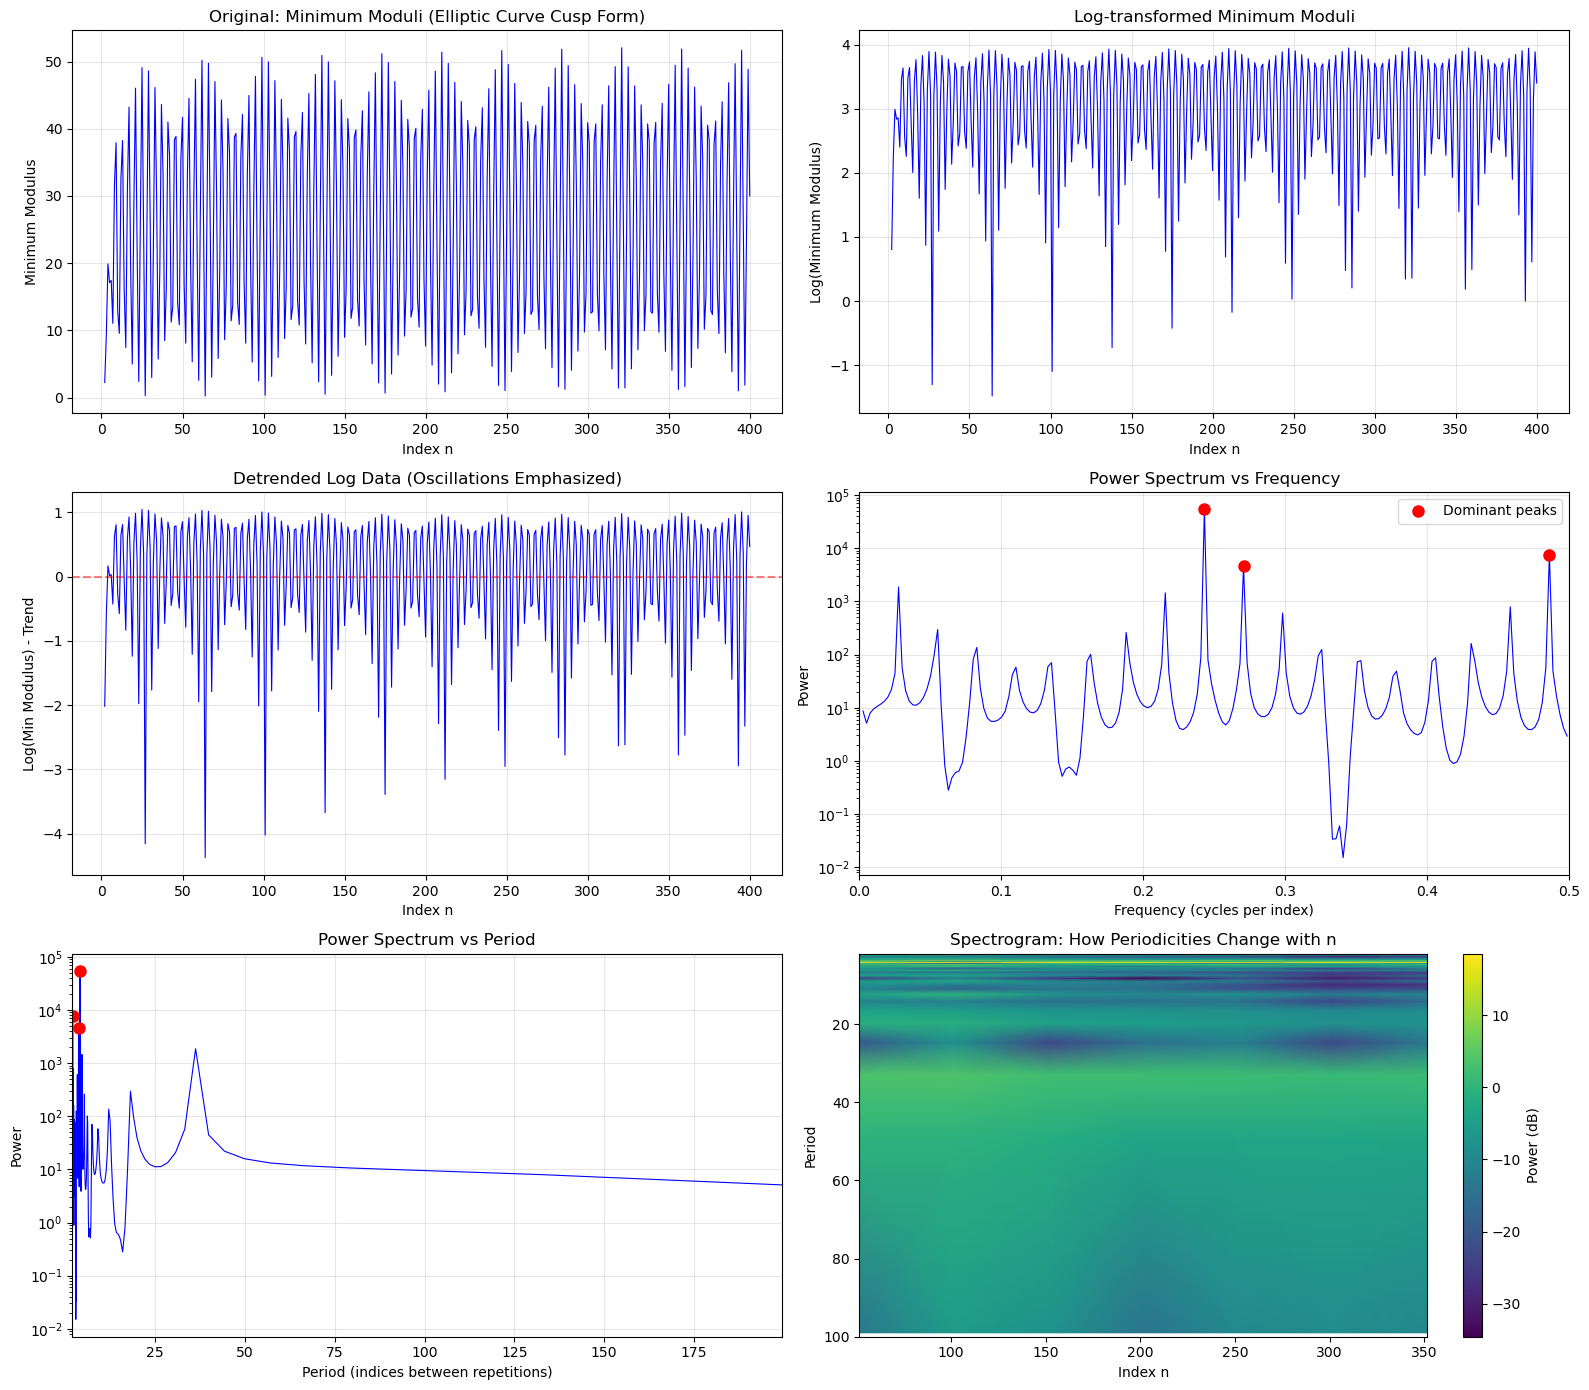


SIGNAL RECONSTRUCTION (using top 5 frequencies)
Component 1: Period = 4.11, Amplitude = 0.0236
Component 2: Period = 2.06, Amplitude = 0.0188
Component 3: Period = 3.69, Amplitude = 0.0206


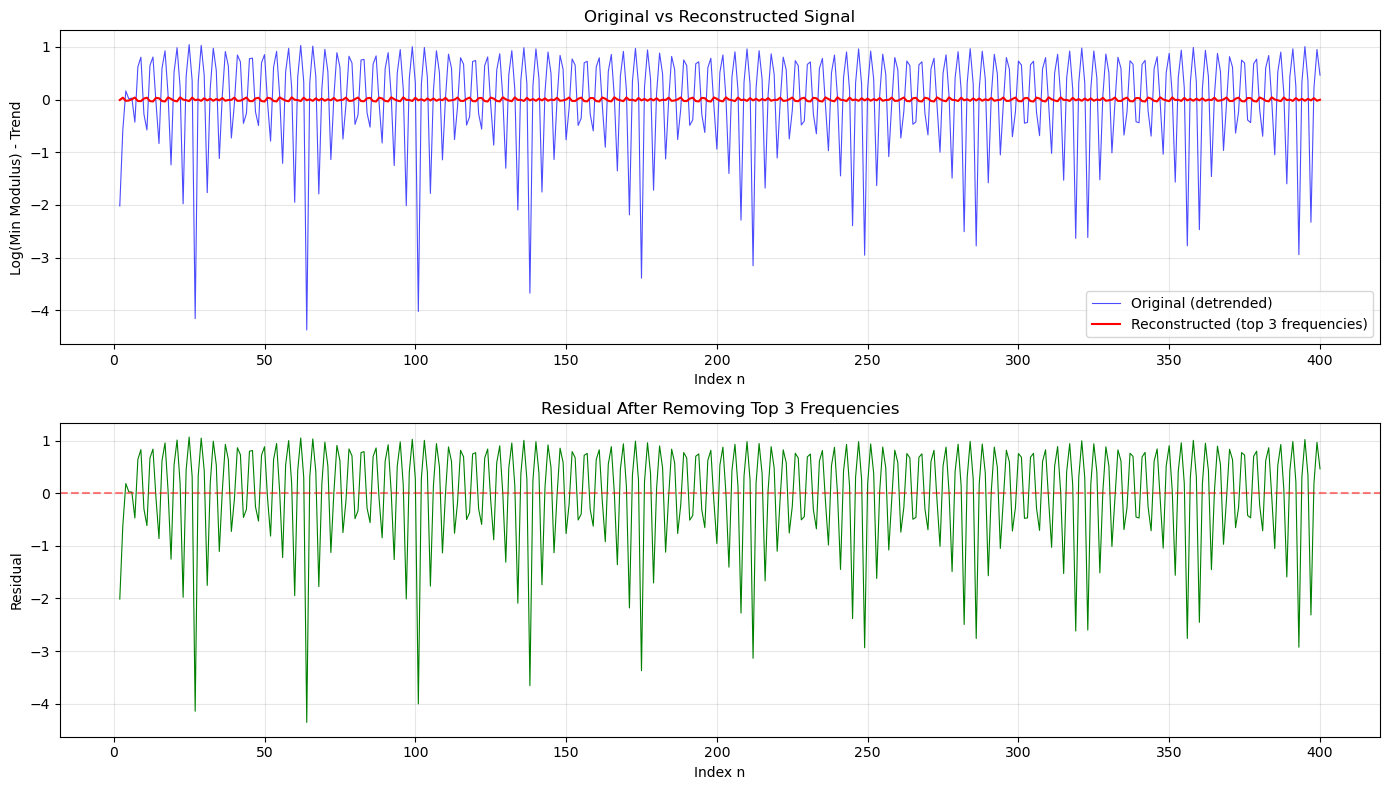


Analysis complete! Examine the plots and frequency table above.


In [2]:
import pickle
from sage.all import sigma, nth_prime, matrix, QQ, ComplexIntervalField, polygen, log, list_plot, flatten, pari


pari.allocatemem(6*10**9) 
print(f"PARI stack size set to: {pari.stacksize() / 1e9:.2f} GB")


_sigma_cache = {}
_nth_prime_cache = {}

def sigma_cached(n):
    if n not in _sigma_cache:
        _sigma_cache[n] = sigma(n)
    return _sigma_cache[n]

def nth_prime_cached(n):
    if n not in _nth_prime_cache:
        _nth_prime_cache[n] = nth_prime(n)
    return _nth_prime_cache[n]

print("Memoization setup complete")


def tau(n):
    def step3(n):
        ans = 0
        n_sq = n * n
        
        
        sigma_vals = [sigma_cached(k) for k in range(1, n)]
        sigma_n_minus_k = [sigma_cached(n - k) for k in range(1, n)]
        
        for k in range(1, n):
            
            k_sq = k * k
            step1_val = 35 * k_sq * k_sq - 52 * k_sq * k * n + 18 * k_sq * n_sq
            
            
            step2_val = sigma_vals[k-1] * sigma_n_minus_k[k-1]
            
            ans += step1_val * step2_val
        
        return 24 * ans
    
    return n**4 * sigma_cached(n) - step3(n)

def h(n):
    
    return tau(nth_prime_cached(n))

print("Functions defined")


print("Computing j_list...")
c = 2 #<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
j_list = [c, 1]

for n in range(2, 401):
    if n % 50 == 0:
        print(f"Progress: n={n}/400")
    
    
    h_vals = [h(n - r) for r in range(1, n)]
    
   
    partial_sum = sum(j_list[r] * h_vals[r-1] for r in range(1, n))
    
    j_n = n * h(n) - partial_sum
    j_list.append(j_n)

print(f"j_list computed with {len(j_list)} elements")


output_path = '/Users/barrybrent/data2/'

with open(output_path + 'run4feb26no6.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile)
    
print(f"j_list saved to {output_path}run27nov25no1.txt")


def P_matrix(lst):
    """Construct P matrix more efficiently"""
    lenlist = len(lst)
    columns = []
    
    
    columns.append(lst)
    
   
    for k in range(1, lenlist):
        column = [0] * (k - 1) + [-k]
        column = flatten(column + [lst])
        column = column[:lenlist]
        columns.append(column)
    
    return matrix(columns).transpose()

print("P_matrix function defined")


precision_bits = 100
CC = ComplexIntervalField(precision_bits)
x = polygen(QQ)

# Pre-allocate lists (NOTE: no matrix_list - saves memory!)
charpol_list = []
roots_list = []
aar_list = []


mins_list = []
log_mins_list = []
maxes_list = []
log_maxes_list = []
dets = []

print("Setup complete for matrix computations")


print("Computing matrices and roots...")
for n in range(2, 401):  # Changed to 401 to match j_list size
    if n % 20 == 0:
        print(f"Progress: n={n}/400")
    
    
    pl = P_matrix(j_list[:n])
    det = pl.det()
    dets.append((n, det))
   
    
    
    cp = pl.charpoly()
    charpol_list.append((n, cp))
    
    
    roots = cp.roots(ring=CC, multiplicities=False)
    roots_list.append((n, roots))
    
    
    
    aar = [r.abs() for r in roots]
    aar_list.append((n, aar))
    
    
    if aar:
        minn = min(aar)
        mins_list.append((n, minn))
        
        if minn > 0:
            log_minn = log(minn)
            log_mins_list.append((n, log_minn))
        
        maxx = max(aar)
        maxes_list.append((n, maxx))
        
        if maxx > 0:
            log_maxx = log(maxx)
            log_maxes_list.append((n, log_maxx))

print("Computation complete!")


print("Generating plots...")

p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()

p = list_plot(log_mins_list, plotjoined=True, axes_labels=['', ''])
print("LOGS MINIMUM MODULI")
p.show()

mml = [pair[1] for pair in log_mins_list]
print("minimum logarithm of minimum modulus:", min(mml))

p = list_plot(maxes_list, plotjoined=True, axes_labels=['', ''])
print("MAXIMUM MODULI")
p.show()

p = list_plot(log_maxes_list, plotjoined=True, axes_labels=['', ''])
print("LOGS MAXIMUM MODULI")
p.show()

  
print("Saving results...")

with open(output_path + 'run4feb26no7.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile)

with open(output_path + 'run4feb26no8.txt', 'wb') as wfile:
    pickle.dump(charpol_list, wfile)

with open(output_path + 'run4feb26no9.txt', 'wb') as wfile:
    pickle.dump(log_mins_list, wfile)

with open(output_path + 'run4feb26no10.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile)

print("All results saved!")
print(f"Output files saved to: {output_path}")

# FOURIER ANALYSIS OF MINIMUM MODULI - Elliptic Curve Cusp Form
# This cell performs spectral analysis on the minimum moduli sequence
# to detect periodicities, dominant frequencies, and oscillatory patterns




import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PREPARE THE DATA - Convert from SageMath to Python/NumPy types
# ==============================================================================

# Extract the data from mins_list and convert to Python floats
# This is crucial because SageMath uses its own numeric types
indices = np.array([float(pair[0]) for pair in mins_list], dtype=np.float64)
min_moduli = np.array([float(pair[1]) for pair in mins_list], dtype=np.float64)

# Also prepare the log-transformed data
log_min_moduli = np.log(min_moduli)

print(f"Data range: n = {int(indices[0])} to {int(indices[-1])}")
print(f"Number of data points: {len(indices)}")
print(f"Min modulus range: {min_moduli.min():.6f} to {min_moduli.max():.6f}")
print(f"Log min modulus range: {log_min_moduli.min():.6f} to {log_min_moduli.max():.6f}")

# ==============================================================================
# 2. DETRENDING (Important for seeing oscillations)
# ==============================================================================

# For the log data, remove any polynomial trend to focus on oscillations
# We'll try both linear and quadratic detrending

# Linear detrend
log_detrended_linear = signal.detrend(log_min_moduli, type='linear')

# Polynomial detrend (degree 2) - captures parabolic growth
poly_coeffs = np.polyfit(indices, log_min_moduli, deg=2)
poly_trend = np.polyval(poly_coeffs, indices)
log_detrended_poly = log_min_moduli - poly_trend

print(f"\nPolynomial trend coefficients: {poly_coeffs}")
print(f"Detrended data std dev: {np.std(log_detrended_poly):.4f}")

# ==============================================================================
# 3. COMPUTE FOURIER TRANSFORM
# ==============================================================================

# Use FFT on the detrended log data
# The FFT reveals which "frequencies" (periodicities in n) are present

fft_result = np.fft.fft(log_detrended_poly)
fft_frequencies = np.fft.fftfreq(len(indices), d=1.0)  # d=1 means indices are spaced by 1

# Power spectrum (magnitude squared)
power_spectrum = np.abs(fft_result)**2

# Only keep positive frequencies (negative are redundant for real signals)
positive_freq_mask = fft_frequencies > 0
frequencies = fft_frequencies[positive_freq_mask]
power = power_spectrum[positive_freq_mask]

# Convert frequency to period: period = 1/frequency
# (period tells us "spikes repeat every X indices")
periods = 1.0 / frequencies

# ==============================================================================
# 4. IDENTIFY DOMINANT FREQUENCIES
# ==============================================================================

# Find peaks in the power spectrum
# Lower threshold to catch more peaks since we have more data (n up to 400)
peak_indices = signal.find_peaks(power, height=np.max(power)*0.05)[0]  # peaks at least 5% of max
peak_powers = power[peak_indices]
peak_periods = periods[peak_indices]

# Sort by power (strongest first)
sorted_indices = np.argsort(peak_powers)[::-1]
top_peaks = sorted_indices[:min(15, len(sorted_indices))]  # Show top 15

print("\n" + "="*70)
print("TOP DOMINANT PERIODICITIES (in index n)")
print("="*70)
print(f"{'Rank':<6} {'Period':<12} {'Frequency':<12} {'Power':<15}")
print("-"*70)
for rank, idx in enumerate(top_peaks, 1):
    period = peak_periods[idx]
    freq = frequencies[peak_indices[idx]]
    pwr = peak_powers[idx]
    print(f"{rank:<6} {period:>10.2f}   {freq:>10.6f}   {pwr:>12.2e}")

# ==============================================================================
# 5. VISUALIZATIONS
# ==============================================================================

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# Plot 5.1: Original data (linear scale)
axes[0, 0].plot(indices, min_moduli, 'b-', linewidth=0.8)
axes[0, 0].set_xlabel('Index n')
axes[0, 0].set_ylabel('Minimum Modulus')
axes[0, 0].set_title('Original: Minimum Moduli (Elliptic Curve Cusp Form)')
axes[0, 0].grid(True, alpha=0.3)

# Plot 5.2: Log scale data
axes[0, 1].plot(indices, log_min_moduli, 'b-', linewidth=0.8)
axes[0, 1].set_xlabel('Index n')
axes[0, 1].set_ylabel('Log(Minimum Modulus)')
axes[0, 1].set_title('Log-transformed Minimum Moduli')
axes[0, 1].grid(True, alpha=0.3)

# Plot 5.3: Detrended data (shows oscillations more clearly)
axes[1, 0].plot(indices, log_detrended_poly, 'b-', linewidth=0.8)
axes[1, 0].set_xlabel('Index n')
axes[1, 0].set_ylabel('Log(Min Modulus) - Trend')
axes[1, 0].set_title('Detrended Log Data (Oscillations Emphasized)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)

# Plot 5.4: Power Spectrum vs Frequency
axes[1, 1].semilogy(frequencies, power, 'b-', linewidth=0.8)
axes[1, 1].semilogy(frequencies[peak_indices[top_peaks]], 
                     peak_powers[top_peaks], 'ro', markersize=8, label='Dominant peaks')
axes[1, 1].set_xlabel('Frequency (cycles per index)')
axes[1, 1].set_ylabel('Power')
axes[1, 1].set_title('Power Spectrum vs Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(0, 0.5)  # Nyquist limit

# Plot 5.5: Power Spectrum vs Period (often more intuitive)
# Only plot periods up to half the data length (longer periods unreliable)
max_period = len(indices) / 2
period_mask = periods <= max_period
axes[2, 0].semilogy(periods[period_mask], power[period_mask], 'b-', linewidth=0.8)
# Mark dominant periods
for idx in top_peaks:
    if peak_periods[idx] <= max_period:
        axes[2, 0].semilogy(peak_periods[idx], peak_powers[idx], 'ro', markersize=8)
axes[2, 0].set_xlabel('Period (indices between repetitions)')
axes[2, 0].set_ylabel('Power')
axes[2, 0].set_title('Power Spectrum vs Period')
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].set_xlim(2, max_period)

# Plot 5.6: Spectrogram (time-frequency analysis using Short-Time Fourier Transform)
# This shows if periodicities change over the sequence
window_size = min(128, len(indices)//4)  # adaptive window size, larger for more data
f_spec, t_spec, Sxx = signal.spectrogram(log_detrended_poly, fs=1.0, 
                                          nperseg=window_size, 
                                          noverlap=window_size//2)
# Convert frequency axis to period for easier interpretation
period_spec = 1.0 / (f_spec + 1e-10)  # avoid division by zero
period_spec = period_spec[1:]  # remove DC component
Sxx = Sxx[1:, :]

# Plot with period on y-axis (inverted so small periods at bottom)
im = axes[2, 1].pcolormesh(indices[0] + t_spec, period_spec, 10*np.log10(Sxx + 1e-10),
                           shading='gouraud', cmap='viridis')
axes[2, 1].set_xlabel('Index n')
axes[2, 1].set_ylabel('Period')
axes[2, 1].set_title('Spectrogram: How Periodicities Change with n')
axes[2, 1].set_ylim(2, min(100, max_period))
axes[2, 1].invert_yaxis()  # small periods at bottom
plt.colorbar(im, ax=axes[2, 1], label='Power (dB)')

plt.tight_layout()
plt.show()

# ==============================================================================
# 6. FILTERED SIGNAL (reconstruct using only dominant frequencies)
# ==============================================================================

# Reconstruct signal using only the top 5 dominant frequencies
# This shows what the "pure" oscillatory pattern looks like

print("\n" + "="*70)
print("SIGNAL RECONSTRUCTION (using top 5 frequencies)")
print("="*70)

reconstructed = np.zeros_like(log_detrended_poly)
num_components = min(5, len(top_peaks))
for rank, idx in enumerate(top_peaks[:num_components], 1):  
    freq = frequencies[peak_indices[idx]]
    period = peak_periods[idx]
    # Get amplitude and phase from FFT
    amp = np.abs(fft_result[peak_indices[idx]]) / len(indices)
    phase = np.angle(fft_result[peak_indices[idx]])
    # Reconstruct this component
    component = amp * np.cos(2 * np.pi * freq * indices + phase)
    reconstructed += component
    print(f"Component {rank}: Period = {period:.2f}, Amplitude = {amp:.4f}")

# Plot comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(indices, log_detrended_poly, 'b-', linewidth=0.8, alpha=0.7, label='Original (detrended)')
axes[0].plot(indices, reconstructed, 'r-', linewidth=1.5, label=f'Reconstructed (top {num_components} frequencies)')
axes[0].set_xlabel('Index n')
axes[0].set_ylabel('Log(Min Modulus) - Trend')
axes[0].set_title('Original vs Reconstructed Signal')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residual (what's left after removing dominant frequencies)
residual = log_detrended_poly - reconstructed
axes[1].plot(indices, residual, 'g-', linewidth=0.8)
axes[1].set_xlabel('Index n')
axes[1].set_ylabel('Residual')
axes[1].set_title(f'Residual After Removing Top {num_components} Frequencies')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Analysis complete! Examine the plots and frequency table above.")
print("="*70)


Data range: n = 2 to 400
Number of data points: 399
Min modulus range: 0.227200 to 52.067661

Detrending: Savitzky-Golay filter, window = 21, poly order = 3
  lag-1 autocorrelation of residuals = 0.0390
  Detrended data std dev: 14.0135

AR(1) lag-1 autocorrelation (rho): 0.0390
Frequency bins tested: 197
Bonferroni-corrected per-bin alpha: 95% -> 0.000254,  99% -> 0.000051

SIGNIFICANT PERIODICITIES  (period <= N/3 = 133, Bonferroni-corrected)
Rank   Period       Frequency    Power           Signif.   
---------------------------------------------------------------------------
1            4.11   0.243108     1.04e+07   99%

  Only one significant peak (period = 4.11); no ratios to compute.


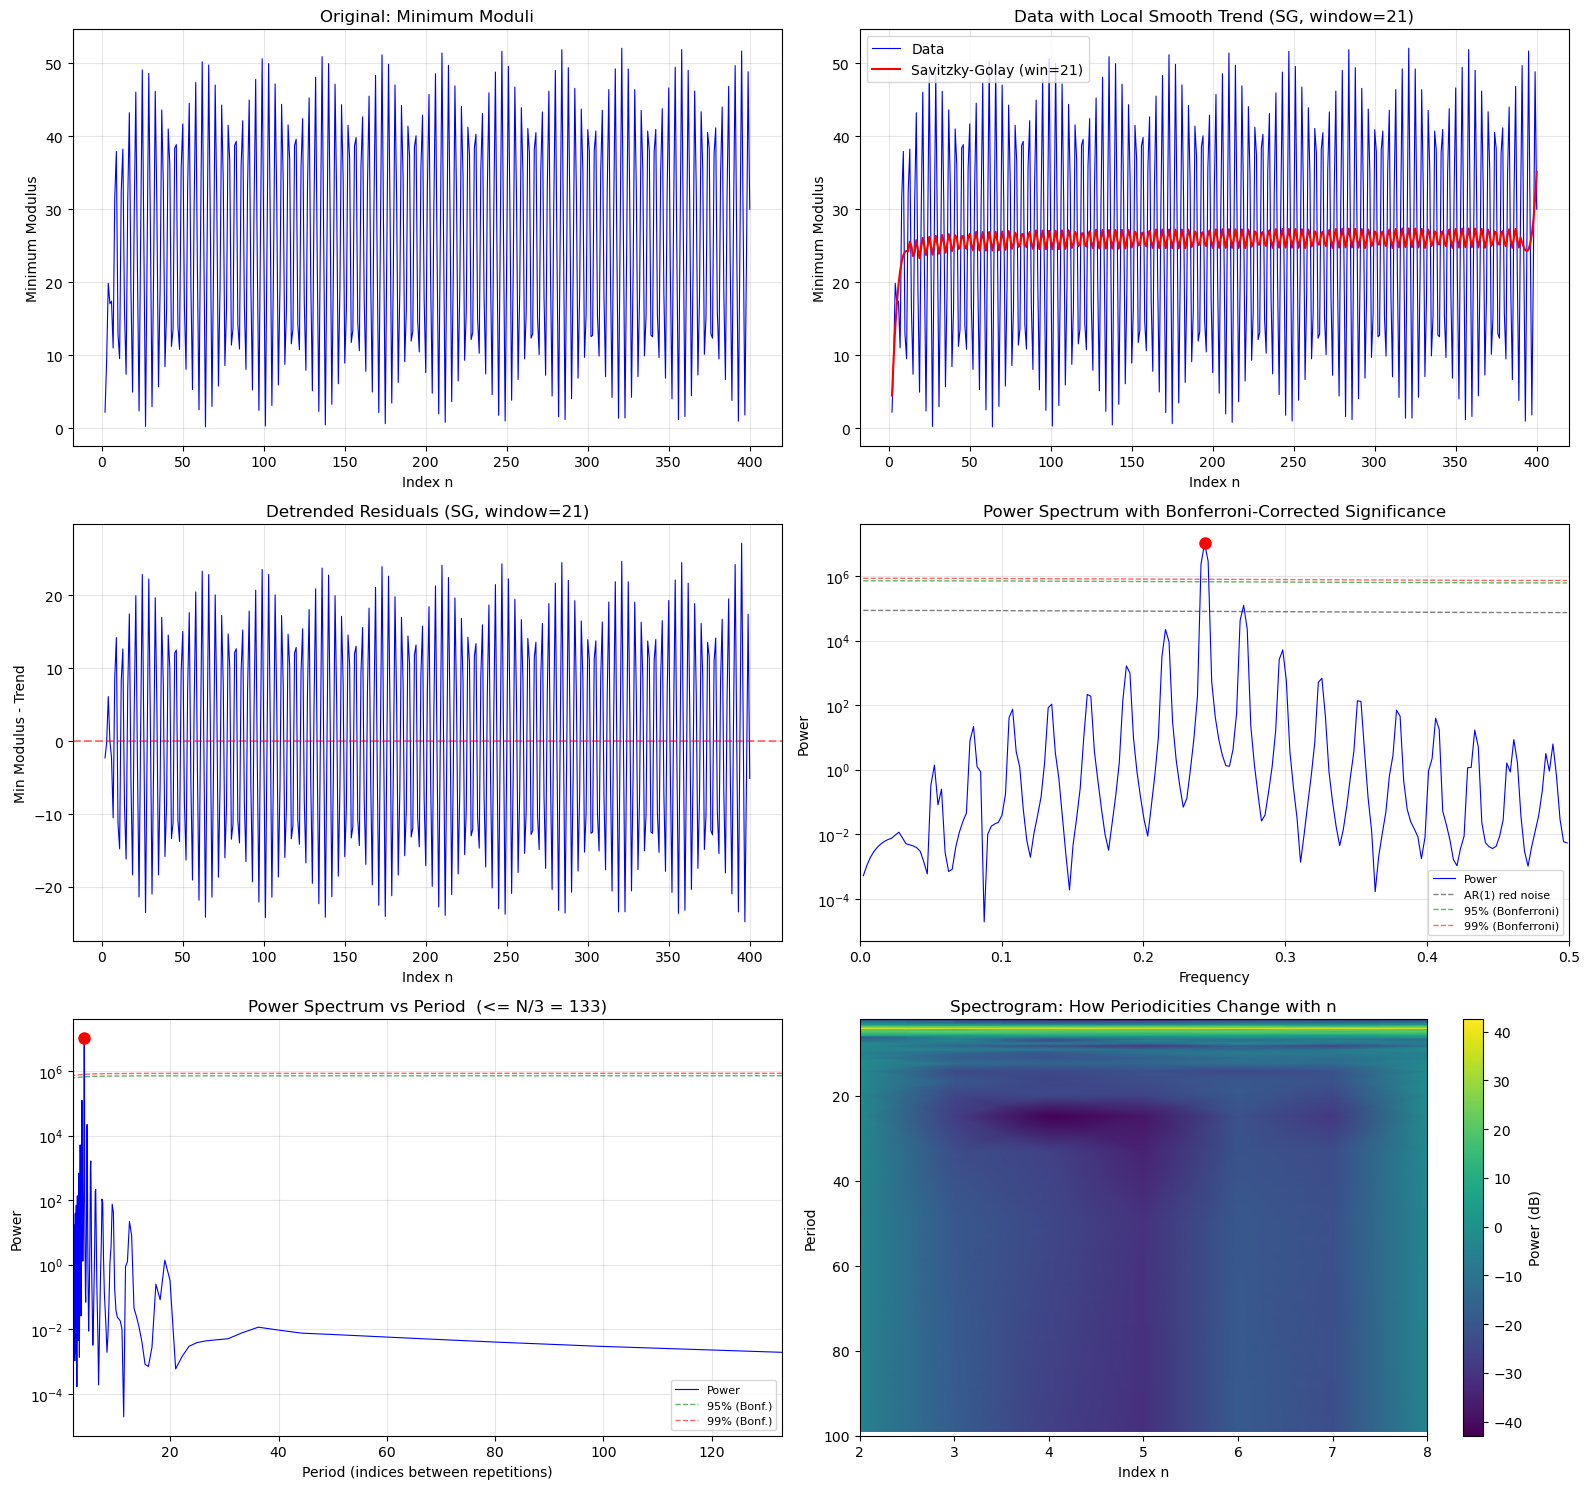


Analysis complete.


In [1]:
import pickle
with open('/Users/barrybrent/data2/run4feb26no10.txt', 'rb') as rfile:
    mins_list = pickle.load(rfile)
# REVISED FOURIER ANALYSIS OF MINIMUM MODULI  (v4)
#
# Key fix in this version: MULTIPLE TESTING CORRECTION.
#
# With N/2 ~ 175 frequency bins, a 95% single-bin threshold will produce
# ~9 false positives purely by chance, even for white noise. Previous
# versions didn't account for this, so plateau noise peaks were
# incorrectly flagged as "significant periodicities."
#
# This version applies a Bonferroni correction: the per-bin significance
# level is divided by the number of independent frequency bins tested,
# so the *family-wise* false positive rate stays at 5% (or 1%).
#
# It expects mins_list to already be defined.

import numpy as np
from scipy import signal, stats
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PREPARE THE DATA
# ==============================================================================
indices   = np.array([float(pair[0]) for pair in mins_list], dtype=np.float64)
minmoduli = np.array([float(pair[1]) for pair in mins_list], dtype=np.float64)
N = len(indices)

print(f"Data range: n = {int(indices[0])} to {int(indices[-1])}")
print(f"Number of data points: {N}")
print(f"Min modulus range: {minmoduli.min():.6f} to {minmoduli.max():.6f}")

# ==============================================================================
# 2. LOCAL SMOOTHING DETREND  (Savitzky-Golay)
# ==============================================================================
sg_poly_order = 3

candidate_windows = [w for w in range(21, min(N//2, 151), 10) if w % 2 == 1]

best_win, best_score = candidate_windows[0], np.inf
sg_results = {}
for win in candidate_windows:
    trend = signal.savgol_filter(minmoduli, window_length=win, polyorder=sg_poly_order)
    resid = minmoduli - trend
    r1 = np.abs(np.corrcoef(resid[:-1], resid[1:])[0, 1])
    sg_results[win] = (trend, resid, r1)
    if r1 < best_score:
        best_score = r1
        best_win = win

smooth_trend, detrended, _ = sg_results[best_win]

print(f"\nDetrending: Savitzky-Golay filter, window = {best_win}, poly order = {sg_poly_order}")
print(f"  lag-1 autocorrelation of residuals = {best_score:.4f}")
print(f"  Detrended data std dev: {np.std(detrended):.4f}")

# ==============================================================================
# 3. WINDOWED FFT
# ==============================================================================
window = np.hanning(N)
windowed = detrended * window
window_power_correction = N / np.sum(window**2)

fft_result     = np.fft.fft(windowed)
fft_freqs      = np.fft.fftfreq(N, d=1.0)
power_spectrum = np.abs(fft_result)**2 * window_power_correction

pos = fft_freqs > 0
frequencies = fft_freqs[pos]
power       = power_spectrum[pos]
periods     = 1.0 / frequencies

# ==============================================================================
# 4. AR(1) RED-NOISE SIGNIFICANCE WITH BONFERRONI CORRECTION
# ==============================================================================
rho = np.corrcoef(detrended[:-1], detrended[1:])[0, 1]
variance = np.var(detrended)

# Theoretical AR(1) power spectrum (Gilman et al. 1963)
ar1_power = (variance * (1 - rho**2)) / (
    1 - 2 * rho * np.cos(2 * np.pi * frequencies) + rho**2
)
ar1_power *= np.mean(power) / np.mean(ar1_power)

# Number of independent frequency bins we're testing
max_credible_period = N / 3.0
credible_mask = periods <= max_credible_period
n_tests = int(np.sum(credible_mask))

# Bonferroni-corrected chi-squared thresholds
# Per-bin alpha = family_alpha / n_tests
alpha_95_corrected = 1.0 - (0.05 / n_tests)
alpha_99_corrected = 1.0 - (0.01 / n_tests)

chi2_95 = stats.chi2.ppf(alpha_95_corrected, df=2) / 2.0
chi2_99 = stats.chi2.ppf(alpha_99_corrected, df=2) / 2.0
conf_95 = ar1_power * chi2_95
conf_99 = ar1_power * chi2_99

print(f"\nAR(1) lag-1 autocorrelation (rho): {rho:.4f}")
print(f"Frequency bins tested: {n_tests}")
print(f"Bonferroni-corrected per-bin alpha: "
      f"95% -> {0.05/n_tests:.6f},  99% -> {0.01/n_tests:.6f}")

# ==============================================================================
# 5. IDENTIFY SIGNIFICANT PEAKS
# ==============================================================================
peak_idx = signal.find_peaks(power, height=0)[0]
significant_peaks = []
for pi in peak_idx:
    if not credible_mask[pi]:
        continue
    if power[pi] > conf_99[pi]:
        significant_peaks.append((pi, '99%'))
    elif power[pi] > conf_95[pi]:
        significant_peaks.append((pi, '95%'))

significant_peaks.sort(key=lambda x: power[x[0]], reverse=True)

print("\n" + "="*75)
print(f"SIGNIFICANT PERIODICITIES  (period <= N/3 = {max_credible_period:.0f}, "
      f"Bonferroni-corrected)")
print("="*75)
if significant_peaks:
    print(f"{'Rank':<6} {'Period':<12} {'Frequency':<12} {'Power':<15} {'Signif.':<10}")
    print("-"*75)
    for rank, (pi, level) in enumerate(significant_peaks[:15], 1):
        print(f"{rank:<6} {periods[pi]:>10.2f} {frequencies[pi]:>10.6f} "
              f"{power[pi]:>12.2e}   {level}")
    # Period ratios: fundamental (rank 1) to each subsequent peak
    if len(significant_peaks) >= 2:
        fund_idx = significant_peaks[0][0]
        fund_period = periods[fund_idx]
        print(f"\n{'':>6}PERIOD RATIOS  (fundamental / peak)")
        print(f"{'':>6}Fundamental period: {fund_period:.2f}")
        print(f"{'':>6}{'-'*55}")
        print(f"{'':>6}{'Rank':<6} {'Period':<12} {'T_fund / T_peak':<18} {'Nearest int':<12}")
        print(f"{'':>6}{'-'*55}")
        for rank, (pi, level) in enumerate(significant_peaks[1:15], 2):
            ratio = fund_period / periods[pi]
            nearest = round(ratio)
            print(f"{'':>6}{rank:<6} {periods[pi]:>10.2f} {ratio:>14.4f}     {nearest:>6}")
    elif len(significant_peaks) == 1:
        print(f"\n  Only one significant peak (period = {periods[significant_peaks[0][0]]:.2f}); "
              f"no ratios to compute.")
else:
    print("  No peaks exceed the Bonferroni-corrected significance threshold.")
    print("  --> The data has no statistically significant periodicity.")
    print("  (Period ratios are not computed when no peaks are significant.)")

# ==============================================================================
# 6. VISUALIZATIONS
# ==============================================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 15))

# 6.1  Original data
axes[0, 0].plot(indices, minmoduli, 'b-', linewidth=0.8)
axes[0, 0].set_xlabel('Index n')
axes[0, 0].set_ylabel('Minimum Modulus')
axes[0, 0].set_title('Original: Minimum Moduli')
axes[0, 0].grid(True, alpha=0.3)

# 6.2  Trend overlay
axes[0, 1].plot(indices, minmoduli, 'b-', linewidth=0.8, label='Data')
axes[0, 1].plot(indices, smooth_trend, 'r-', linewidth=1.5,
                label=f'Savitzky-Golay (win={best_win})')
axes[0, 1].set_xlabel('Index n')
axes[0, 1].set_ylabel('Minimum Modulus')
axes[0, 1].set_title(f'Data with Local Smooth Trend (SG, window={best_win})')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 6.3  Detrended data
axes[1, 0].plot(indices, detrended, 'b-', linewidth=0.8)
axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Index n')
axes[1, 0].set_ylabel('Min Modulus - Trend')
axes[1, 0].set_title(f'Detrended Residuals (SG, window={best_win})')
axes[1, 0].grid(True, alpha=0.3)

# 6.4  Power spectrum with corrected confidence bands
axes[1, 1].semilogy(frequencies, power, 'b-', linewidth=0.8, label='Power')
axes[1, 1].semilogy(frequencies, ar1_power, 'k--', linewidth=1,
                    alpha=0.5, label='AR(1) red noise')
axes[1, 1].semilogy(frequencies, conf_95, 'g--', linewidth=1,
                    alpha=0.6, label='95% (Bonferroni)')
axes[1, 1].semilogy(frequencies, conf_99, 'r--', linewidth=1,
                    alpha=0.6, label='99% (Bonferroni)')
for pi, level in significant_peaks:
    color = 'red' if level == '99%' else 'orange'
    axes[1, 1].semilogy(frequencies[pi], power[pi], 'o',
                        color=color, markersize=8)
axes[1, 1].set_xlabel('Frequency')
axes[1, 1].set_ylabel('Power')
axes[1, 1].set_title('Power Spectrum with Bonferroni-Corrected Significance')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(0, 0.5)

# 6.5  Power spectrum vs period
pmask = (periods <= max_credible_period) & (periods >= 2)
axes[2, 0].semilogy(periods[pmask], power[pmask], 'b-', linewidth=0.8,
                    label='Power')
axes[2, 0].semilogy(periods[pmask], conf_95[pmask], 'g--', linewidth=1,
                    alpha=0.6, label='95% (Bonf.)')
axes[2, 0].semilogy(periods[pmask], conf_99[pmask], 'r--', linewidth=1,
                    alpha=0.6, label='99% (Bonf.)')
for pi, level in significant_peaks:
    if periods[pi] <= max_credible_period:
        color = 'red' if level == '99%' else 'orange'
        axes[2, 0].semilogy(periods[pi], power[pi], 'o',
                            color=color, markersize=8)
axes[2, 0].set_xlabel('Period (indices between repetitions)')
axes[2, 0].set_ylabel('Power')
axes[2, 0].set_title(f'Power Spectrum vs Period  (<= N/3 = {max_credible_period:.0f})')
axes[2, 0].legend(fontsize=8)
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].set_xlim(2, max_credible_period)

# 6.6  Spectrogram
window_size = min(128, N // 4)
fspec, tspec, Sxx = signal.spectrogram(detrended, fs=1.0,
                                       nperseg=window_size,
                                       noverlap=window_size // 2)
periodspec = 1.0 / (fspec[1:] + 1e-10)
Sxx = Sxx[1:, :]
im = axes[2, 1].pcolormesh(indices[:len(tspec)], periodspec,
                           10 * np.log10(Sxx + 1e-10),
                           shading='gouraud', cmap='viridis')
axes[2, 1].set_xlabel('Index n')
axes[2, 1].set_ylabel('Period')
axes[2, 1].set_title('Spectrogram: How Periodicities Change with n')
axes[2, 1].set_ylim(2, min(100, max_credible_period))
axes[2, 1].invert_yaxis()
plt.colorbar(im, ax=axes[2, 1], label='Power (dB)')

plt.tight_layout()
plt.show()

print("\n" + "="*75)
print("Analysis complete.")
print("="*75)
